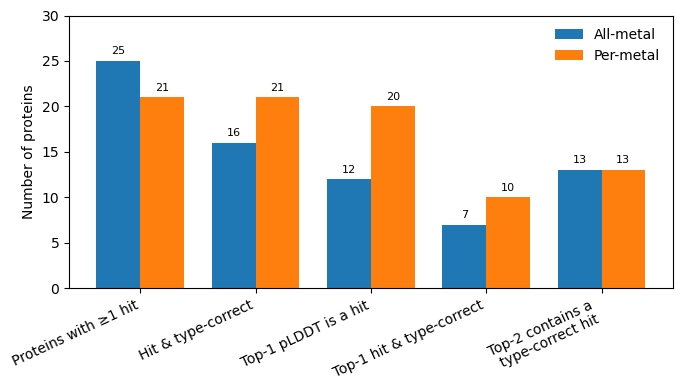

In [1]:
import matplotlib.pyplot as plt
import numpy as np

settings = [
    "Proteins with ≥1 hit",
    "Hit & type-correct",
    "Top-1 pLDDT is a hit",
    "Top-1 hit & type-correct",
    "Top-2 contains a\n type-correct hit",
]

all_metal = [25, 16, 12, 7, 13]
per_metal = [21, 21, 20, 10, 13]

x = np.arange(len(settings))
width = 0.38

fig, ax = plt.subplots(figsize=(7, 4))

bars1 = ax.bar(x - width/2, all_metal, width, label="All-metal")
bars2 = ax.bar(x + width/2, per_metal, width, label="Per-metal")

# 값 라벨
for bars in [bars1, bars2]:
    for b in bars:
        height = b.get_height()
        ax.text(
            b.get_x() + b.get_width()/2,
            height + 0.5,
            f"{int(height)}",
            ha="center", va="bottom", fontsize=8
        )

ax.set_ylabel("Number of proteins")
ax.set_xticks(x)
ax.set_xticklabels(settings, rotation=25, ha="right")
ax.legend(frameon=False)
ax.set_ylim(0, 30)

fig.tight_layout()
plt.show()


/home/qkrgangeun/mambaforge/envs/se3_113/lib/python3.9/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/qkrgangeun/mambaforge/envs/se3_113/lib/python3.9/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/tmp/ipykernel_28946/782623831.py:54: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(ax.get_xticklabels(), rotation=25, ha="right")


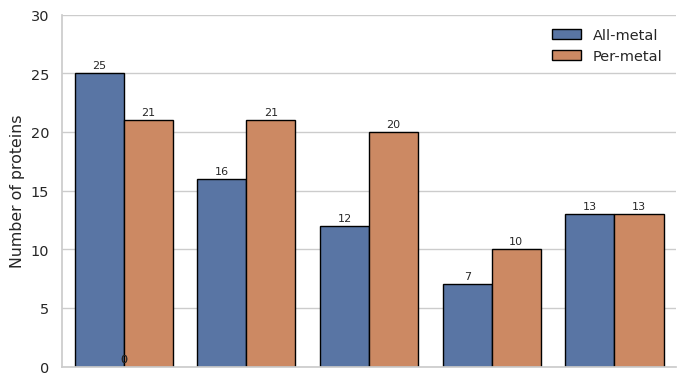

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 데이터 정리
data = {
    "Setting": [
        "Proteins with ≥1 hit",
        "Hit & type-correct",
        "Top-1 pLDDT is a hit",
        "Top-1 hit & type-correct",
        "Top-2 contains a type-correct hit",
        "Proteins with ≥1 hit",
        "Hit & type-correct",
        "Top-1 pLDDT is a hit",
        "Top-1 hit & type-correct",
        "Top-2 contains a type-correct hit",
    ],
    "Evaluation": [
        "All-metal", "All-metal", "All-metal", "All-metal", "All-metal",
        "Per-metal", "Per-metal", "Per-metal", "Per-metal", "Per-metal",
    ],
    "Count": [25, 16, 12, 7, 13, 21, 21, 20, 10, 13],
}

df = pd.DataFrame(data)

# seaborn 스타일
# sns.set_theme(style="whitegrid")

plt.figure(figsize=(7, 4))
ax = sns.barplot(
    data=df,
    x="Setting",
    y="Count",
    hue="Evaluation",
    edgecolor="black"
)

# 값 라벨 표시
for p in ax.patches:
    height = p.get_height()
    ax.annotate(
        f"{int(height)}",
        (p.get_x() + p.get_width() / 2., height),
        ha="center", va="bottom",
        xytext=(0, 2),
        textcoords="offset points",
        fontsize=8
    )

ax.set_ylabel("Number of proteins")
ax.set_xlabel("")
ax.set_xticklabels(ax.get_xticklabels(), rotation=25, ha="right")
ax.legend(title="", frameon=False)
ax.set_ylim(0, 30)

sns.despine()
plt.tight_layout()
plt.show()


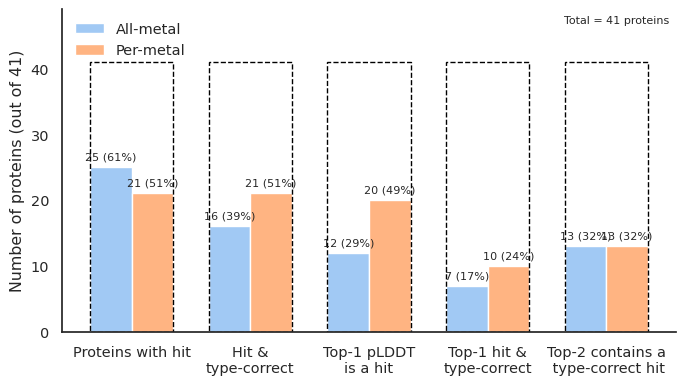

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Rectangle

# ----- 데이터 -----
total_proteins = 41

settings = [
    "Proteins with hit",
    "Hit &\ntype-correct",
    "Top-1 pLDDT\nis a hit",
    "Top-1 hit &\ntype-correct",
    "Top-2 contains a\n type-correct hit",
]

all_metal = [25, 16, 12, 7, 13]
per_metal = [21, 21, 20, 10, 13]

# seaborn용 tidy 데이터프레임
df = pd.DataFrame({
    "Setting": settings * 2,
    "Evaluation": ["All-metal"] * len(settings) + ["Per-metal"] * len(settings),
    "Count": all_metal + per_metal,
})
df["Percent"] = df["Count"] / total_proteins * 100

# ----- 스타일 -----
sns.set_theme(style='white',font_scale=0.95)
palette = sns.color_palette("pastel", 2)

fig, ax = plt.subplots(figsize=(7, 4))

x = np.arange(len(settings))
width = 0.35

# 막대 그리기 (색은 seaborn 팔레트)
bars_all = ax.bar(x - width/2, all_metal, width,
                  label="All-metal", color=palette[0])
bars_per = ax.bar(x + width/2, per_metal, width,
                  label="Per-metal", color=palette[1])

# ----- 카테고리마다 '전체 41개'를 나타내는 점선 박스 (두 막대를 함께 감싸도록) -----
for xi in x:
    rect = Rectangle(
        (xi - width, 0),    # x 시작점
        2 * width,          # 두 막대 폭 합친 만큼
        total_proteins,     # 높이 = 41
        fill=False,
        linestyle="--",
        linewidth=1,
        edgecolor="black"
    )
    ax.add_patch(rect)

# ----- 막대 위에 개수 + 퍼센트 라벨 -----
def annotate(bars):
    for b in bars:
        h = b.get_height()
        pct = h / total_proteins * 100
        ax.text(
            b.get_x() + b.get_width() / 2,
            h + 0.8,
            f"{int(h)} ({pct:.0f}%)",
            ha="center", va="bottom",
            fontsize=8
        )

annotate(bars_all)
annotate(bars_per)

# ----- 축/범례/텍스트 정리 -----
ax.set_ylim(0, total_proteins + 8)
ax.set_ylabel("Number of proteins (out of 41)")
ax.set_xlabel("")
ax.set_xticks(x)
ax.set_xticklabels(settings)

ax.legend(title="", frameon=False, loc="upper left")

# 오른쪽 위에 전체 개수 표기
ax.text(
    0.99, 0.98,
    "Total = 41 proteins",
    transform=ax.transAxes,
    ha="right", va="top",
    fontsize=8
)

sns.despine()
fig.tight_layout()
plt.show()


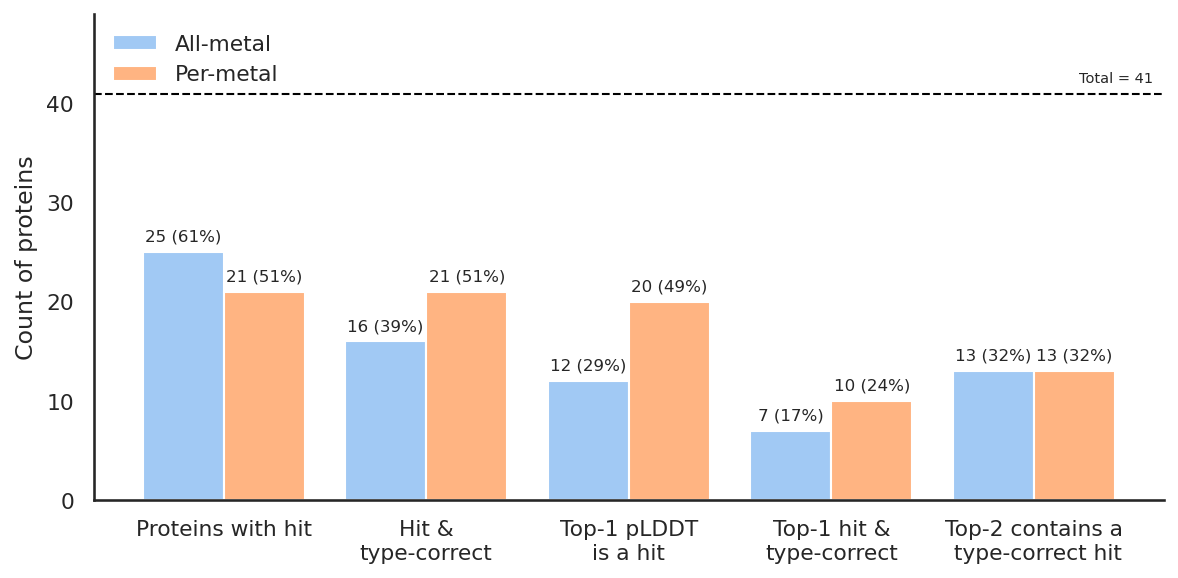

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 고해상도 설정 (모니터 / 저장 둘 다)
plt.rcParams["figure.dpi"] = 150       # 노트북/화면 표시용
plt.rcParams["savefig.dpi"] = 300      # 저장 시 해상도
plt.rcParams["pdf.fonttype"] = 42      # pdf에서 글꼴 깨지지 않게
plt.rcParams["ps.fonttype"] = 42

# ----- 데이터 -----
total_proteins = 41

settings = [
    "Proteins with hit",
    "Hit &\ntype-correct",
    "Top-1 pLDDT\nis a hit",
    "Top-1 hit &\ntype-correct",
    "Top-2 contains a\n type-correct hit",
]

all_metal = [25, 16, 12, 7, 13]
per_metal = [21, 21, 20, 10, 13]

df = pd.DataFrame({
    "Setting": settings * 2,
    "Evaluation": ["All-metal"] * len(settings) + ["Per-metal"] * len(settings),
    "Count": all_metal + per_metal,
})
df["Percent"] = df["Count"] / total_proteins * 100

# ----- 스타일 -----
sns.set_theme(style="white", font_scale=0.95)
palette = sns.color_palette("pastel", 2)

fig, ax = plt.subplots(figsize=(8, 4))  # 필요하면 8,4 대신 더 크게

x = np.arange(len(settings))
width = 0.40

# 막대
bars_all = ax.bar(x - width/2, all_metal, width,
                  label="All-metal", color=palette[0])
bars_per = ax.bar(x + width/2, per_metal, width,
                  label="Per-metal", color=palette[1])

# 전체 41개 기준선
ax.axhline(
    y=total_proteins,
    linestyle="--",
    linewidth=1,
    color="black"
)
ax.text(
    0.99, total_proteins + 0.8,
    "Total = 41",
    ha="right", va="bottom",
    transform=ax.get_yaxis_transform(),
    fontsize=7
)

# 라벨
def annotate(bars):
    for b in bars:
        h = b.get_height()
        pct = h / total_proteins * 100
        ax.text(
            b.get_x() + b.get_width() / 2,
            h + 0.8,
            f"{int(h)} ({pct:.0f}%)",
            ha="center", va="bottom",
            fontsize=8
        )

annotate(bars_all)
annotate(bars_per)

ax.set_ylim(0, total_proteins + 8)
ax.set_ylabel("Count of proteins")
ax.set_xlabel("")
ax.set_xticks(x)
ax.set_xticklabels(settings)
ax.legend(title="", frameon=False, loc="upper left")

sns.despine()
fig.tight_layout()

plt.show()

# 논문용 저장 (벡터 포맷 권장)
fig.savefig("promet_hit_summary.pdf", bbox_inches="tight")   # 벡터
# 또는 고해상도 png
# fig.savefig("promet_hit_summary.png", dpi=300, bbox_inches="tight")


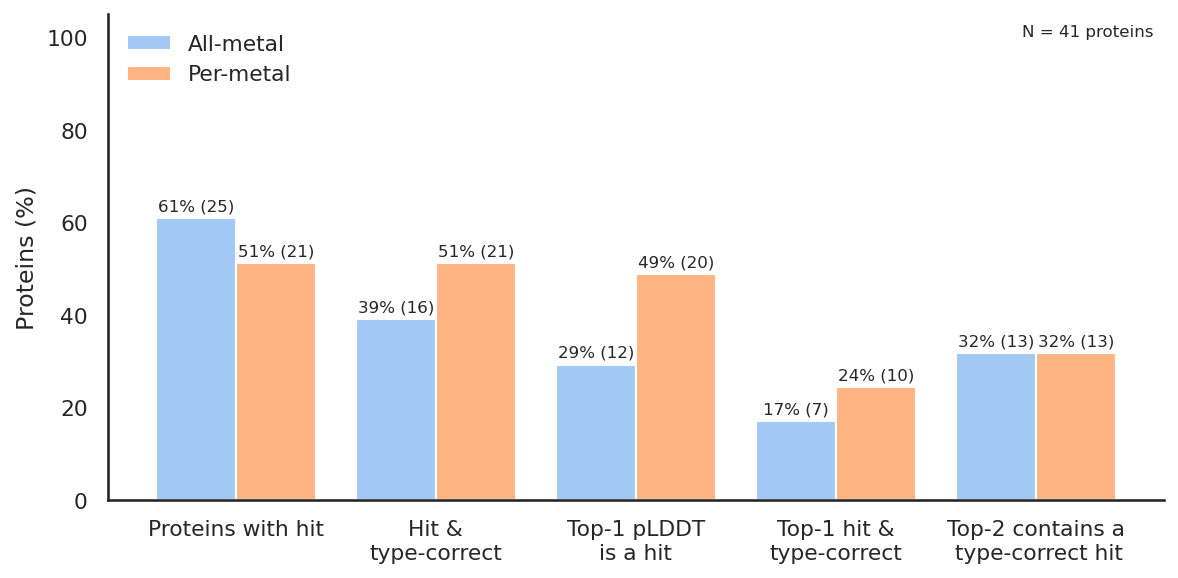

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 고해상도 설정
plt.rcParams["figure.dpi"] = 150
plt.rcParams["savefig.dpi"] = 300
plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42

# ----- 데이터 -----
total_proteins = 41

settings = [
    "Proteins with hit",
    "Hit &\ntype-correct",
    "Top-1 pLDDT\nis a hit",
    "Top-1 hit &\ntype-correct",
    "Top-2 contains a\n type-correct hit",
]

all_metal = np.array([25, 16, 12, 7, 13])
per_metal = np.array([21, 21, 20, 10, 13])

# 퍼센트로 변환
all_metal_pct = all_metal / total_proteins * 100
per_metal_pct = per_metal / total_proteins * 100

# ----- 스타일 -----
sns.set_theme(style="white", font_scale=0.95)
palette = sns.color_palette("pastel", 2)

fig, ax = plt.subplots(figsize=(8, 4))

x = np.arange(len(settings))
width = 0.40

# 막대 (높이는 퍼센트)
bars_all = ax.bar(x - width/2, all_metal_pct, width,
                  label="All-metal", color=palette[0])
bars_per = ax.bar(x + width/2, per_metal_pct, width,
                  label="Per-metal", color=palette[1])

# 막대 위 라벨: "xx% (count)"
def annotate(bars, counts):
    for b, c in zip(bars, counts):
        h = b.get_height()  # percent
        ax.text(
            b.get_x() + b.get_width() / 2,
            h + 1,
            f"{h:.0f}% ({int(c)})",
            ha="center", va="bottom",
            fontsize=8
        )

annotate(bars_all, all_metal)
annotate(bars_per, per_metal)

# ----- 축 / 범례 -----
ax.set_ylim(0, 105)  # 0–100% + 여유
ax.set_ylabel("Proteins (%)")
ax.set_xlabel("")
ax.set_xticks(x)
ax.set_xticklabels(settings)
ax.legend(title="", frameon=False, loc="upper left")

# 전체 개수 표시
ax.text(
    0.99, 0.98,
    "N = 41 proteins",
    transform=ax.transAxes,
    ha="right", va="top",
    fontsize=8
)

sns.despine()
fig.tight_layout()
plt.show()

# 저장 (원하면 주석 해제)
# fig.savefig("promet_hit_summary_percent.pdf", bbox_inches="tight")
